## Esercizio 1

In [1]:
from scipy.io import loadmat
import numpy as np
from SolveTriangular import *
from numpy import linalg as lin
from scipy import linalg as splin
from numpy.linalg import norm
import matplotlib.pyplot as plt
from itertools import takewhile
from gradient import steep

err_rel = lambda x, px: norm(x-px) / norm(x)

dati = loadmat('Test_I.mat')
A = dati['A']
A = A.astype(float)
b = dati['b']
b = b.astype(float)
b = b.ravel()


In [12]:
def cho_solve(A, b):
    L = lin.cholesky(A)
    return Usolve(L.T.copy(), Lsolve(L, b))

def iterate(func, start):
    while True:
        yield start
        start = func(*start)

def iterative(A, b, func, M, N, name, x0=None, toll=1e-10, itmax=1000):
    if x0 is None:
        x0 = np.zeros_like(b) + 0.1
    err = lambda x, px: lin.norm(x-px) / lin.norm(x)
    
    stop_criteria = lambda i, args: i < itmax and (args[1] >= toll)
    
    spectrum = np.max(np.abs(lin.eigvals(splin.inv(M) @ N)))
    print(f"Raggio spettrale → {spectrum} ({name})")
    if spectrum >= 1:
        print('La soluzione non converge')
        return x0, 1, [1]

    iter = iterate(lambda x, rel, prev_x: (func(x), err(x, prev_x), x), (x0+0.1, 1, 0))
    arr = list(dict(takewhile(lambda param: stop_criteria(*param), enumerate(iter))).values()) + [next(iter)]
    
    return arr[-1][0], len(arr), [err for _, err, _ in arr]

def jacobi(A,b, x0=None, toll=1e-10, itmax=100):
    D = np.diag(A)
    M = np.diagflat(D)
    N = A - M
    return iterative(A, b, lambda x: (b - N @ x) / D, M, N, 'jacobi')

def gauss_seidel(A,b, x0=None, toll=1e-10, itmax=100):
    F = np.triu(A, 1)
    M = A - F
    return iterative(A, b, lambda x: Lsolve(M, b - F @ x), M, -F, 'gauss-seidel')

def min_omega(A):
    F = np.triu(A, 1)
    E = np.tril(A,-1)
    D = A - (E + F)
    
    def spectrum(D, E, F, omega):
        M = D + omega * E
        N = (1-omega) * D - omega*F
        return np.max(np.abs(lin.eigvals(splin.inv(M) @ N)))
                      
    x = np.arange(1.7,2.0, 0.1)
    y = [spectrum(D, E, F, i) for i in x]
    min_spectrum = np.min(y)
    for i in x:
        h = spectrum(D, E, F, i)
        if h == min_spectrum:
            min_omega = i
    
    return min_omega, min_spectrum, x, y

def plot_best_omega(*args):
    i, m, x, y = args
    plt.title(r"Trend showcasing best $\omega_{ottimo}$ for Gauss-Seidel-Sor")
    plt.plot(x, y)
    plt.scatter(i, m, color='red')
    plt.legend([r"$\omega_{ottimo} → " + f"{i:.4}$"])
    plt.show()

def gauss_seidel_sor(A,b, omega=1.5, x0=None, toll=1e-10, itmax=100):
    F = np.triu(A, 1)
    E = np.tril(A,-1)
    M = A - F
    D = A - (E + F)
    # omega, _, _, _ = min_omega(A)
    Momg = D + omega * E
    Nomg = (1-omega) * D - omega*F
    return iterative(A, b, lambda x: (x + omega * ((Lsolve(M, b - F @ x) - x))), Momg, Nomg, 'gauss-seidel-sor')
    
def conjugate_gradient(A, b, itmax=100, toll=1e-10):
    alfa = lambda A, res, p: res @ res / (A @ p @ p)
    def p(nres, res, p): 
        gamma = nres @ nres / (res @ res)
        return -nres + (gamma * p)
    return steep(A, b, alfa, p, itmax=itmax, toll=toll)

def steepscent(A, b, itmax=1000, toll=1e-10):
    alfa = lambda A, res, p: -res @ p / (A @ p @ p)
    p = lambda res, _, p: -res
    return steep(A, b, alfa, p, itmax=itmax, toll=toll)

def plot_error(args):
    _, it, err = args
    plt.semilogy(range(it), err, '-')
    print(it)

def test_convergence(A, b, methods = {'jacobi': jacobi, 'gauss-seidel': gauss_seidel,}):
    # nb.display(nb.Markdown('## Matrix is:\n'))
    # display_matrix(A, notation=f'A')
    plt.title('Convergence comparison between iterative methods')
    [plot_error(meth(A, b)) for meth in methods.values()]
    plt.legend(methods.keys())
    print()
    plt.show()



In [13]:
def gauss_seidel_sor1(A,b,omega=1.5, it_max=1000, toll=1e-10):
    x0=np.zeros_like(b)
    errore=1000
    d = np.diag(A)
    D=np.diag(d)
    E= np.tril(A,-1)
    F= np.triu(A,1)
    #Calcolo della matrice di iterazione di Gassu_Seidel SOR
    Momega=D+omega*E
    Nomega=(1-omega)*D-omega*F
    T=np.dot(lin.inv(Momega),Nomega)
    eigv = lin.eigvals(T)
    raggiospettrale= np.max(np.abs(eigv))
    print("raggio spettrale Gauss-Seidel SOR ", raggiospettrale)
    
    M= D+E
    N= -F
    it=0
    xold=x0.copy()
    xnew=x0.copy()
    er_vet=[]
    while it<=it_max and errore>=toll:
        tmp = b - np.dot(F,xold)
        xtilde = Lsolve(M,tmp) 
        xnew= (1-omega)*xold+omega*xtilde
        errore= lin.norm(xnew - xold)/lin.norm(xnew)
        er_vet.append(errore)
        xold=xnew.copy()
        it=it+1
    return xnew,it,er_vet

Indice di condizionamento → 178.06427461086116
Raggio spettrale → 0.9888308262251364 (jacobi)
1001
Raggio spettrale → 0.9777864028930788 (gauss-seidel)
842
raggio spettrale Gauss-Seidel SOR  0.9316897358159115
576
Raggio spettrale → 0.9316897358159115 (gauss-seidel-sor)
572
42
1001



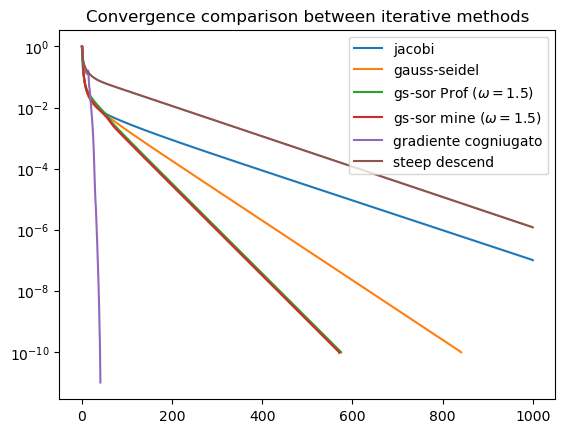

In [14]:
assert np.allclose(A, A.T)
assert all(np.r_[np.isreal(lin.eigvals(A)), lin.eigvals(A) > 0])
print(f'Indice di condizionamento → {lin.cond(A)}')
# i, m, x, y = min_omega(A)
i = 1.5
methods = {'jacobi': jacobi, 
           'gauss-seidel': gauss_seidel, 
           r'gs-sor Prof ($\omega='+f"{i:.3}"+')$': gauss_seidel_sor1,
           r'gs-sor mine ($\omega='+f"{i:.3}"+')$': gauss_seidel_sor,
           r'gradiente cogniugato': conjugate_gradient,
           r'steep descend': steepscent
          }
test_convergence(A, b, methods=methods)
# plot_best_omega(i, m, x, y)